# Informações Gerais sobre o Conteúdo

---

### Uso de Inteligência Artificial
Este projeto utilizou ferramentas de IA como assistentes de coprodução. O objetivo principal deste documento é servir como uma fonte sólida de dados e material para estudos posteriores.

* **O que foi aprimorado por IA:** A otimização de trechos de código e o refinamento técnico das descrições dos métodos.
* **O que é de autoria própria:** Toda a formulação teórica, estruturação do projeto, arquitetura da API e a lógica de utilização foram planejadas e escritas pelo autor, assim como a elaboração da grande maioria dos códigos contidos aqui.

> **Resumo:** A IA funcionou como um copiloto para refinar o trabalho, mas a direção, a arquitetura e a execução principal são 100% humanas.

In [3]:
# Imports básicos
from mpl_toolkits.mplot3d import Axes3D
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from collections import deque
import random
import os
import pickle
import csv

from numpy.linalg import svd
from scipy.stats import chi2, norm, f
from IPython.display import display, Markdown
from numba import njit

# --- Verificação e Instalação do CoppeliaSim ---
try:
    from coppeliasim_zmqremoteapi_client import RemoteAPIClient 
    print("Biblioteca CoppeliasimZMQ já instalada")
except ImportError:
    print("Biblioteca CoppeliasimZMQ NÃO instalada. Instalando...")
    !pip install coppeliasim-zmqremoteapi-client
    from coppeliasim_zmqremoteapi_client import RemoteAPIClient 
    print("Biblioteca CoppeliasimZMQ instalada com sucesso!")

# --- Verificação e Instalação do PyTorch ---
try:
    import torch
    import torch.nn as nn
    import torch.optim as optim
    import torch.nn.functional as F
    print("Biblioteca PyTorch já instalada")
except ImportError:
    print("Biblioteca PyTorch NÃO instalada. Instalando...")
    !pip install torch
    import torch
    import torch.nn as nn
    import torch.optim as optim
    import torch.nn.functional as F
    print("Biblioteca PyTorch instalada com sucesso!")

Biblioteca CoppeliasimZMQ já instalada
Biblioteca PyTorch já instalada


# Sobre a atividade

Aqui será desenvolvido um algorítmo para controle de um robô num ambiente desconhecido mediante a técnica Q-Learning, e finaliznado com a técnica TOSL-iBSR (True Online SARSA Informed-Based softmax regression)

- **Primeira etapa:** Desenvolvimento dos algorítmos básicos (Controle do robô)
- **Segunda etapa:** Cadeias de Markov (Teoria e implementações)
- **Terceira etapa:** Algorítmo de recompensa e Reinforced Learning
- **Quarta etapa:** Arquitetura TOSL-iBSR
- **Quinta Etapa:** Testes de rendimento para cada arquitetura

# 1. Primeira Etapa: Controle do Robô

## 1.1 Simulação no Coppelia

### Arquitetura do Sistema de Simulação

Este ecossistema utiliza a biblioteca de API Remota baseada em ZeroMQ (`coppeliasim_zmqremoteapi_client`) para estabelecer comunicação síncrona bidirecional com o simulador CoppeliaSim. A arquitetura divide-se logicamente em três componentes principais estruturados em Programação Orientada a Objetos (POO):

* **Classe `Simulation`**: Orquestrador genérico do loop de simulação. Gerencia a inicialização da conexão de rede, o relógio interno do motor de física e força o modo de execução síncrono.
* **Classe `Pioneer`**: Interface de baixo nível que abstrai o hardware do robô, lidando com a leitura de sensores reais do cenário e a atuação nos motores.
* **Classe `LyapunovController`**: Implementação matemática do algoritmo de controle de postura em malha fechada.

In [4]:
class Simulation:
    def __init__(self, max_time=30.0):
        self.max_time = max_time
        self.current_time = 0.0
        self.is_running = False
        
        # Initialize Remote API Client connection
        self.client = RemoteAPIClient()
        self.sim = self.client.getObject('sim')
        
        self.robot = None
        self.controller = None

    def setup(self):
        """Override to configure your scene objects."""
        pass

    def loop(self):
        """Override to program execution logic."""
        pass

    def stop(self):
        """Overrride to programa stop logic. """
        self.robot.stop()
        self.sim.stopSimulation()
        print(f"Simulation execution halted at {self.current_time:.2f} seconds.")
        
    def run(self):
        """Executes the synchronous simulation step loop inside CoppeliaSim."""
        self.setup()
        
        if self.robot is None:
            raise TypeError("Runtime Error: 'self.robot' must be initialized inside setup().")

        # Enable Synchronous stepping mode
        self.sim.setStepping(True)
        self.sim.startSimulation()
        self.is_running = True
        print("CoppeliaSim synchronous simulation initialized.")
        
        while self.is_running and self.current_time < self.max_time:
            # Get internal simulation clock time from engine
            self.current_time = self.sim.getSimulationTime()
            
            # Execute user-overridden logic loop
            self.loop()
            
            # Trigger physics step computation engine forward
            self.sim.step()

            #Add some timeout in the controller?
            
        # Stopping sequence execution
        self.stop()

## 1.2. Definindo robô Pionner

### O Robô Pioneer e a Abstração de Hardware

O robô que será utilizado nesta simulação é o **Pioneer**. Este modelo possui um anel com **16 sensores ultrassônicos** associados a ele, o que o torna uma plataforma altamente interessante para tarefas de navegação e percepção de ambiente. 

Para integrá-lo adequadamente, e considerando que estamos operando via API ZeroMQ do CoppeliaSim, será necessário definir uma classe dedicada (a classe `Pioneer`). Essa abordagem orientada a objetos nos permite abstrair toda a complexidade do controle de baixo nível, organizando a interação com o simulador em três frentes principais:

* **Percepção (Sensores):** Leitura contínua do array de ultrassons para medir a distância de possíveis obstáculos.
* **Cinemática (Atuação):** Conversão das velocidades de controle linear e angular em comandos de rotação individuais para os motores direito e esquerdo.
* **Localização (Pose):** Extração precisa da **pose** global do robô — ou seja, suas coordenadas espaciais cartesianas ($x, y$) e sua orientação/guiada ($\theta$) — em relação ao referencial absoluto do ambiente de simulação.

Essa estruturação torna o código limpo, modular e pronto para ser reutilizado facilmente em experimentos futuros.ros.

In [5]:
class Pioneer:
    def __init__(self, sim, robot_path='/PioneerP3DX'):
        """
        sim: The CoppeliaSim API instance object ('sim')
        robot_path: The base path of the Pioneer model in the scene hierarchy
        """
        self.sim = sim
        
        # Pioneer 3-DX physical specifications
        self.r = 0.0975  # Wheel radius (meters)
        self.L = 0.381   # Wheelbase track width (meters)

        # max 
        self.v_max = 1.6 # m/s
        self.w_max = 5.23 # rad/s
        
        # Fetch object handles from the CoppeliaSim scene hierarchy
        self.robot_handle = self.sim.getObject(robot_path)
        self.left_motor = self.sim.getObject(f"{robot_path}/leftMotor")
        self.right_motor = self.sim.getObject(f"{robot_path}/rightMotor")
        
        # Fetch handles for the 16 proximity sensors (sonars)
        # Note: Adjust the naming format string if your scene uses a different pattern
        self.sonar_handles = []
        for i in range(16):
            try:
                handle = self.sim.getObject(f"{robot_path}/sonar[{i}]")
                self.sonar_handles.append(handle)
            except Exception:
                # Fallback for alternative scene configurations (e.g., ultrasonicSensor[x])
                handle = self.sim.getObject(f"{robot_path}/ultrasonicSensor[{i}]")
                self.sonar_handles.append(handle)

    def get_pose(self):
        """
        Retrieves the absolute 2D pose (x, y, theta) from the simulator.
        Uses sim.handle_world (-1) as the reference frame.
        """
        position = self.sim.getObjectPosition(self.robot_handle, self.sim.handle_world)
        orientation = self.sim.getObjectOrientation(self.robot_handle, self.sim.handle_world)
        
        x = position[0]
        y = position[1]
        theta = orientation[2]  # Yaw angle around Z axis
        return np.array([x, y, theta])

    def send_commands(self, v, omega):
        """
        Inverse Kinematics: Computes wheel velocities and sends them to CoppeliaSim.
        """
        #clip velocities
        v = np.clip(v, -self.v_max, self.v_max)
        omega = np.clip(omega, -self.w_max, self.w_max)
        
        # Diferential equations
        w_r = (v + (omega * self.L) / 2.0) / self.r
        w_l = (v - (omega * self.L) / 2.0) / self.r

        
        self.sim.setJointTargetVelocity(self.left_motor, w_l)
        self.sim.setJointTargetVelocity(self.right_motor, w_r)

    def read_sonars(self):
        """
        Reads the 16 proximity sensors from the scene.
        Returns a NumPy array containing the detected distances.
        """
        distances = []
        for handle in self.sonar_handles:
            # sim.readProximitySensor returns: [result, distance, detectedPoint, detectedObjectHandle, detectedSurfaceNormalVector]
            result, distance, _, _, _ = self.sim.readProximitySensor(handle)
            
            if result > 0:
                distances.append(distance)
            else:
                distances.append(5.0)  # Max range default value if no obstacle detected
                
        return np.array(distances)

    def read_sonars_dict(self):
        """
        Read all sensor data and returns a dict with the correct information for each step.
        """
        distances = self.read_sonars()
        
        return {
            "front_left": distances[0:3],    # Sonars 0, 1, 2
            "front_center": distances[3:5],  # Sonars 3, 4 (Directly in the front center)
            "front_right": distances[5:8],   # Sonars 5, 6, 7
            "rear_right": distances[8:11],   # Sonars 8, 9, 10
            "rear_center": distances[11:13], # Sonars 11, 12
            "rear_left": distances[13:16]    # Sonars 13, 14, 15
        }

    def get_specific_sonars(self, indices):
        """
        Returns readings only from the requested sonars.
        Usage example: robot.get_specific_sonars([3, 4]) # Gets only the front sonars
        """
        distances = self.read_sonars() # Fetches all using your original method
        
        # Filters and returns a dictionary with only the desired indices
        resultado = {}
        for i in indices:
            if 0 <= i < 16:
                resultado[f"sonar_{i}"] = distances[i]
            else:
                print(f"Warning: Sonar {i} does not exist. Choose an index between 0 and 15.")
                
        return resultado
    
        
    def stop(self):
        """stops the robot Pionner"""
        self.send_commands(0,0)
        
# Class to a Dummy in the simulation
class Dummy:
    def __init__(self, sim, obj_path=None):
        """
        sim: The CoppeliaSim API instance object ('sim')
        robot_path: The base path of the Pioneer model in the scene hierarchy
        """
        self.sim = sim
        
        # Fetch object handles from the CoppeliaSim scene hierarchy
        self.obj_handle = self.sim.getObject(obj_path)
        
    def get_pose(self):
        """
        Retrieves the absolute 2D pose (x, y, theta) from the simulator.
        Uses sim.handle_world (-1) as the reference frame.
        """
        position = self.sim.getObjectPosition(self.obj_handle, self.sim.handle_world)
        orientation = self.sim.getObjectOrientation(self.obj_handle, self.sim.handle_world)
        
        x = position[0]
        y = position[1]
        theta = orientation[2]  # Yaw angle around Z axis
        return np.array([x, y, theta])

# 2. Segunda Etapa: Fundamentos de Aprendizado por Reforço

O Aprendizado por Reforço baseia-se no paradigma de aprendizado orientado a objetivos por meio da interação direta entre um agente computacional e um ambiente dinâmico. Diferentemente do aprendizado supervisionado, o agente não recebe instruções explícitas sobre qual ação tomar, dependendo exclusivamente de uma sequência de sinais escalares de recompensa para otimizar seu comportamento de longo prazo.


## 2.1. Processos de Decisão de Markov (MDP)

A formulação matemática canônica de um problema de RL é governada pela estrutura de um **Processo de Decisão de Markov (MDP)**. Formalmente, um MDP é definido por uma tupla quíntupla $\mathcal{M} = \langle \mathcal{S}, \mathcal{A}, \mathcal{P}, \mathcal{R}, \gamma \rangle$, em que:

- $\mathcal{S}$ é o espaço de estados (podendo ser discreto ou contínuo).
- $\mathcal{A}$ é o espaço de ações disponíveis ao agente.
- $\mathcal{P}: \mathcal{S} \times \mathcal{A} \times \mathcal{S} \rightarrow [0, 1]$ representa a função de transição probabilística de estados, satisfazendo a propriedade de Markov:
  $$
  \mathcal{P}(s' \mid s, a) = \mathbb{P}(S_{t+1} = s' \mid S_t = s, A_t = a)
  $$
  A propriedade estabelece que o estado futuro $S_{t+1}$ depende exclusivamente do estado atual $S_t$ e da ação corrente $A_t$, sendo condicionalmente independente do histórico de estados e ações pregressos.
- $\mathcal{R}: \mathcal{S} \times \mathcal{A} \times \mathcal{S} \rightarrow \mathbb{R}$ define a função de recompensa, cujo valor esperado é expresso por:
  $$
  \mathcal{R}(s, a) = \mathbb{E}[R_{t+1} \mid S_t = s, A_t = a]
  $$
- $\gamma \in [0, 1)$ denota o fator de desconto intertemporal, responsável por ponderar o valor de utilidade de recompensas imediatas em relação a recompensas futuras e assegurar a convergência matemática em horizontes de tempo infinitos.

O objetivo principal do agente é determinar uma política $\pi(a \mid s) = \mathbb{P}(A_t = a \mid S_t = s)$ que maximize o retorno acumulado descontado esperado a partir do tempo $t$, definido formalmente como:

$$
G_t = \sum_{k=0}^{\infty} \gamma^k R_{t+k+1}
$$

## 2.2. Funções de Valor e as Equações de Bellman

Para mensurar a qualidade de um estado ou de um par estado-ação sob uma determinada política $\pi$, definem-se duas funções de valor fundamentais:

- **Função de Valor de Estado ($V^\pi(s)$):** Mensura o retorno esperado a partir do estado $s$ seguindo a política $\pi$.
  $$
  V^\pi(s) = \mathbb{E}_\pi \left[ G_t \mid S_t = s \right]
  $$
- **Função de Valor de Ação ($Q^\pi(s, a)$):** Também conhecida como *Q-value*, quantifica o retorno esperado ao executar a ação $a$ no estado $s$, e, subsequente a isso, adotar a política $\pi$.
  $$
  Q^\pi(s, a) = \mathbb{E}_\pi \left[ G_t \mid S_t = s, A_t = a \right]
  $$

Por meio do princípio de otimalidade de Bellman, estas funções podem ser decompostas de forma recursiva. A **Equação de Otimidade de Bellman para o $Q$-value**, que assume que o agente adotará a política ideal $\pi^*$ em todos os passos subsequentes, é formulada como:

$$
Q^*(s, a) = \mathcal{R}(s, a) + \gamma \sum_{s' \in \mathcal{S}} \mathcal{P}(s' \mid s, a) \max_{a' \in \mathcal{A}} Q^*(s', a')
$$

## 2.3. Aprendizado por Diferença Temporal (TD) e Q-learning


A resolução analítica da Equação da Otimidade de Bellman exige o conhecimento completo do modelo dinâmico do ambiente, especificamente das probabilidades de transição $\mathcal{P}(s' \mid s, a)$. Na maioria das aplicações de engenharia e robótica, este modelo é desconhecido ou intratável computacionalmente. Surge então a necessidade de métodos de aprendizado livres de modelo (*model-free*).
#
## Aprendizado por Diferença Temporal

O Aprendizado por Diferença Temporal (TD) unifica as vantagens dos métodos de Monte Carlo (aprendizado baseado em experiência direta livre de modelo) e de Programação Dinâmica (atualização baseada em estimativas parciais sem a necessidade do término do episódio, processo denominado *bootstrapping*). 

A atualização mais elementar, denominada $\text{TD}(0)$, ajusta a estimativa de valor $V(S_t)$ em direção a um alvo atualizado após um único passo de transição, conforme a equação abaixo:

$$
V(S_t) \leftarrow V(S_t) + \alpha \delta_t
$$

Onde $\alpha \in (0, 1]$ representa a taxa de aprendizado e $\delta_t$ denota o **Erro de Diferença Temporal (Erro TD)**, definido por:

$$
\delta_t = R_{t+1} + \gamma V(S_{t+1}) - V(S_t)
$$

O termo $R_{t+1} + \gamma V(S_{t+1})$ é matematicamente conhecido como o **Alvo TD*#* (*TD Target*).

## O Algoritmo Q-Learning Tabular

O algoritmo Q-Learning, proposto por Watkins (1989), estende o princípio de diferença temporal para o aprendizado fora de política (*off-policy*) das funções de valor de ação $Q(s, a)$. A regra de atualização assintótica do Q-Learning tabular é expressa por:

$$
Q(S_t, A_t) \leftarrow Q(S_t, A_t) + \alpha \left[ R_{t+1} + \gamma \max_{a} Q(S_{t+1}, a) - Q(S_t, A_t) \right]
$$

Sob a premissa de que todos os pares estado-ação sejam visitados infinitas vezes e que a taxa de aprendizado satisfaça as condições de convergência estocástica de Robbins-Monro, provou-se que $Q(s,a)$ converge com probabilidade $1$ para o valor ótimo $Q^*(s,a)$.

## 2.4. Deep Q-Networks (DQN)

### Aproximação de Funções e Deep Q-Networks (DQN)

Embora o Q-Learning tabular seja matematicamente robusto, sua aplicabilidade prática desmorona diante do fenômeno conhecido como a **maldição da dimensionalidade** (*curse of dimensionality*). Em ambientes reais, como jogos complexos ou sistemas de navegação robótica com sensores contínuos, o número de estados tende ao infinito, tornando inviável o armazenamento e preenchimento de uma tabela clássica de estados por ações.
#
## Aproximação Paramétrica de Funções

Para contornar essa restrição, substitui-se a tabela por um aproximador de funções parametrizado por um vetor de pesos $\theta \in \mathbb{R}^d$. Redes Neurais Profundas (*Deep Neural Networks* - DNN) atuam como aproximadores não-lineares universais eficientes, mapeando estados de alta dimensionalidade diretamente para estimativas de $Q$-values:

$$
Q(s, a; \theta) \approx Q^*(s, a)
$$

O algoritmo *Deep Q-Network* (DQN), proposto por Mnih et al. (2015), viabilizou o treinamento estável de tais redes por meio da introdução de duas técnicas fundamentais:

1. **Buffer de Retrocesso de Experiências (*Experience Replay* $\mathcal{D}$):** Armazena as transições escalares do agente $(S_t, A_t, R_{t+1}, S_{t+1})$ em uma memória circular. Mini-batches são amostrados uniformemente de forma aleatória para quebrar a correlação temporal intrínseca das trajetórias consecutivas, garantindo a premissa de dados independentes e identicamente distribuídos (i.i.d.) necessária para a otimização de gradiente descendente.
2. **Rede Alvo (*Target Network* $\theta^-$):** Introduz uma segunda rede estável cuja única função é computar o alvo de treino de Bellman. Seus pesos $\theta^-$ permanecem congelados por um determinado período de iterações, mitigando o problema de instabilidade em que os alvos de treinamento deslocam-se simultaneamente com as atualizações da rede principal (problema análogo a "perseguir um alvo em movimento").

O Alvo de Bellman do DQN tradicional baseia-se na equação abaixo:

$$
Y_t^{\text{DQN}} = R_{t+1} + \gamma \max_{a} Q(S_{t+1}, a; \theta_t^-)
$$

## 2.5. O algorítmo Double Deep Q-Network (DDQN)

$\newcommand{\argmax}{\operatorname*{argmax}}$
Apesar dos avanços do DQN, a arquitetura clássica sofre de um obstáculo matemático severo: o **viés de superestimação** (*overestimation bias*). Proposto por Hasselt, Guez e Silver (2016), o algoritmo *Double Deep Q-Network* (DDQN) modifica diretamente o cálculo do Alvo de Bellman para isolar e neutralizar esse erro sistemático.

### 2.5.1. O Viés de Superestimação

A falha intrínseca à formulação tradicional do DQN reside no uso do operador de maximização ($\max_a$). Este operador utiliza o mesmo conjunto de parâmetros $\theta_t^-$ tanto para **selecionar** a ação de maior valor quanto para **estimar** o valor bruto dessa ação no próximo estado $S_{t+1}$. 

Como os estimadores baseados em redes profundas possuem ruídos e imprecisões localizadas causadas por amostragem limitada, o operador de máximo propaga e acumula sistematicamente os erros positivos mais altos. Analiticamente, demonstra-se por meio da Desigualdade de Jensen que se as estimativas de $Q(s,a)$ forem variáveis aleatórias com média equivalente ao valor real $Q^*(s,a)$, o valor esperado do máximo será estritamente superior ao máximo do valor esperado:

$$
\mathbb{E}\left[\max_a X_a\right] \geq \max_a \mathbb{E}[X_a]
$$

Este otimismo excessivo gera instabilidade severa na política, fazendo com que o agente superestime rotas subótimas e perigosas, estagnando o processo de convergência.

### 2.5.2. O Mecanismo de Desacoplamento Algorítmico

A formulação do Double DQN elimina esse viés ao promover o completo **desacoplamento** entre o processo de seleção da ação futura e o processo de avaliação do valor correspondente a ela no estado subsequente $S_{t+1}$. A operação matemática é dividida de forma simétrica entre as duas redes neurais existentes no sistema:

1. **Seleção da Ação:** A **Rede Principal** (*Online Network*), parametrizada pelos pesos atuais $\theta_t$, avalia o menu de ações discretas e indica aquela que maximiza o retorno predito através do operador $\max$ implícito na busca do argumento ótimo:
   $$
   a^* = \argmax_{a} Q(S_{t+1}, a; \theta_t)
   $$
2. **Avaliação da Ação:** A **Rede Alvo** (*Target Network*), parametrizada pelos pesos estáveis $\theta_t^-$, é encarregada de mensurar de forma neutra o valor estrito de $Q$ associado à ação previamente selecionada pela rede principal:
   $$
   V_{\text{estimado}} = Q(S_{t+1}, a^*; \theta_t^-)
   $$

Combinando os passos, o Alvo de Bellman do DDQN ($Y_t^{\text{DDQN}}$) passa a ser regido de forma estrita pela equação abaixo:

$$
Y_t^{\text{DDQN}} = R_{t+1} + \gamma Q\left(S_{t+1}, \argmax_{a} Q(S_{t+1}, a; \theta_t); \theta_t^-\right)
$$

Esta separação garante que erros de aproximação temporários na rede online não inflacionem o alvo de treino de forma direta, mitigando o viés de superestimação.

### 2.5.3. Função de Perda e Otimização de Pesos

O treinamento dos parâmetros $\theta_t$ da Rede Principal ocorre minimizando-se de forma iterativa a função de perda pelo Erro Quadrático Médio (*Mean Squared Error* - MSE) sob transições obtidas via amostragem do buffer $\mathcal{D}$:

$$
\mathcal{L}(\theta_t) = \mathbb{E}_{(S_t,A_t,R_{t+1},S_{t+1}) \sim \mathcal{D}} \left[ \left( Y_t^{\text{DDQN}} - Q(S_t, A_t; \theta_t) \right)^2 \right]
$$

Derivando-se a função de perda com relação ao vetor de parâmetros ativos $\theta_t$, extrai-se o gradiente analítico para retropropagação:

$$
\nabla_{\theta_t} \mathcal{L}(\theta_t) = -2 \cdot \mathbb{E} \left[ \left( Y_t^{\text{DDQN}} - Q(S_t, A_t; \theta_t) \right) \cdot \nabla_{\theta_t} Q(S_t, A_t; \theta_t) \right]
$$

A atualização dos pesos segue o algoritmo de gradiente descendente estocástico (otimizado comumente via algoritmo Adam com taxa de aprendizado hiperparamétrica $\alpha$):

$$
\theta_{t+1} \leftarrow \theta_t - \alpha \cdot \nabla_{\theta_t} \mathcal{L}(\theta_t)
$$

### 2.5.4 Estabilização via Atualização Suave (Soft Update)

Ao invés de realizar cópias completas e abruptas de $\theta$ para $\theta^-$ em intervalos fixos largos (técnica que pode reintroduzir instabilidade), adota-se a técnica de *Soft Update* baseada na ponderação exponencial de Polyak. Os parâmetros da rede alvo rastreiam as evoluções da rede online de forma infinitesimal a cada iteração $t$, obedecendo à seguinte regra de atualização:

$$
\theta_{t+1}^- \leftarrow \tau \theta_{t+1} + (1 - \tau) \theta_t^-
$$

Onde $\tau \ll 1$ (frequentemente configurado como $\tau = 0.005$) funciona como um filtro passa-baixas matemático, amortecendo a variação dos alvos computados e promovendo suavidade ao longo do ciclo de treinamento.

# 3. Terceira Etapa: Metodologia de testes



## 3.1. O Novo Espaço de Estados (Inputs da Rede)

O conceito de grid (células discretas de $6 \times 6$ metros) foi removido. A rede neural agora interage com um ambiente puramente contínuo, recebendo um vetor de **18 valores numéricos** a cada ciclo de decisão:

* **16 valores (Percepção de Obstáculos):** Leituras normalizadas dos sensores ultrassônicos (sonares), indicando a distância exata dos obstáculos ao redor do robô.
* **1 valor (Distância):** Distância euclidiana atual do centro do robô até o alvo final.
* **1 valor (Orientação):** Ângulo relativo do alvo em relação à frente do robô (normalizado entre $-\pi$ e $\pi$). Se o valor for positivo, o alvo está para a esquerda; se for negativo, o alvo está para a direita.

## 3.2. O Novo Espaço de Ações (Outputs da Rede)

Para otimizar o aprendizado e estabilizar a navegação, a arquitetura DDQN simplificou o problema adotando um espaço de ações **discreto**. A velocidade linear ($V$) do robô é mantida estritamente constante em **$0.15$ m/s** (movimento contínuo para frente).

A última camada da rede neural gera **5 Q-Values**, representando a "nota" prevista para as seguintes 5 opções de velocidade angular ($\omega$) disponíveis para o robô:

* **Ação 0:** $-1.5$ rad/s (Curva acentuada à direita)
* **Ação 1:** $-0.75$ rad/s (Curva leve à direita)
* **Ação 2:** $0.0$ rad/s (Movimento reto em direção ao alvo)
* **Ação 3:** $0.75$ rad/s (Curva leve à esquerda)
* **Ação 4:** $1.5$ rad/s (Curva acentuada à esquerda)

## 3.3. A Nova Função de Recompensa (Reward Design)

De acordo com a metodologia do artigo de referência, a função de recompensa foi elaborada para medir a eficiência rigorosa das ações a cada estado, incentivando a aproximação constante ao objetivo e punindo comportamentos evasivos ou colisões.

A recompensa total $R$ em cada passo de tempo é definida por uma função condicional, dependendo fortemente do estado terminal ou de navegação do ambiente:

$$R = 
\begin{cases} 
500 & \text{se o alvo for alcançado (Sucesso)} \\
-100 & \text{se houver colisão com qualquer obstáculo (Falha)} \\
R_{\text{passo}} & \text{caso contrário (Navegação Livre)}
\end{cases}$$

Durante a navegação, a recompensa contínua ($R_{\text{passo}}$) é dada pela combinação de métricas de postura e deslocamento direcional:

$$R_{\text{passo}} = R_\theta + R_d + R_{\text{approach}}$$

* **A Bússola Direcional ($R_\theta$):** Avalia se o robô está apontando na direção correta. O robô recebe uma recompensa $R_\theta \ge 0$ se o seu ângulo relativo em relação ao objetivo estiver entre $-90^\circ$ e $+90^\circ$ ($-\pi/2$ a $\pi/2$). Caso o robô se vire para as costas do alvo (ângulo fora desse intervalo frontal), a recompensa passa a ser estritamente negativa ($R_\theta < 0$).
* **O Progresso de Distância ($R_d$):** Avalia o movimento progressivo comparado ao passo anterior. Se a distância atual do robô ao alvo for estritamente menor que a distância passada, ele recebe uma recompensa alta ($R_d > 2$). Se o robô ficar estagnado ou a distância aumentar, ele ganha uma pontuação reduzida ($1 < R_d \le 2$).
* **Feedback de Deslocamento Físico ($R_{\text{approach}}$):** Este é o componente de maior peso no controle contínuo. O agente recebe uma grande recompensa de $+100$ sempre que se aproxima fisicamente da localização do alvo, e sofre uma punição igualmente severa de $-100$ caso se afaste.

**Nota sobre a fase de exploração:** Devido ao forte peso das recompensas de $+100$ e $-100$ em cada ciclo, o robô é forçado a abandonar trajetórias curvas desnecessárias e buscar uma navegação em linha reta o mais rápido possível, otimizando o caminho e punindo qualquer recuo no mapa de forma severa.

## 3.4. Metodologia de Avaliação e Análise Estatística (DRL)

Ao utilizar a arquitetura *Double Deep Q-Network* (que implementa duas redes neurais: a Principal e a Alvo, para evitar o superotimismo na matemática de Bellman), a convergência deixa de ser mapeada célula a célula e passa a ser estocástica (probabilística). O agente explora via decaimento de Epsilon, ajusta seus pesos e, gradativamente, estabiliza sua política de controle.

Para validar o treinamento com rigor estatístico, a metodologia de testes focará em duas frentes de visualização ao final do treinamento:

1. **Evolução do Retorno (Curva de Aprendizado):** Analisa a soma de recompensas por episódio. Espera-se uma curva com alta variância e ruído inicial (fase alta de exploração aleatória) que ascende e se estabiliza em um platô estritamente positivo nas etapas finais do treino.
2. **Mapa de Convergência Espacial (Convergence Map):** Um mapeamento topológico em 2D que plota o local exato onde o robô encerrou cada episódio. Utilizando um gradiente de cores para representar a passagem do tempo (do episódio 0 ao limite final), este mapa serve como prova geométrica de que o robô parou de colidir nos arredores (episódios iniciais) e passou a convergir ativamente para dentro do raio do alvo (episódios finais).lvo (episódios finais).

In [13]:
class DDQNNetwork(nn.Module):
    def __init__(self, input_dim=18, num_actions=5):
        super(DDQNNetwork, self).__init__()
        # A rede recebe o estado (18 valores) e cospe 5 Q-Values (um para cada ação)
        self.fc1 = nn.Linear(input_dim, 128)
        self.fc2 = nn.Linear(128, 128)
        self.fc3 = nn.Linear(128, 64)
        self.q_out = nn.Linear(64, num_actions) 

    def forward(self, state):
        x = F.relu(self.fc1(state))
        x = F.relu(self.fc2(x))
        x = F.relu(self.fc3(x))
        return self.q_out(x) # Sem ativação final, pois Q-Values podem ser infinitos

class ReplayBuffer:
    def __init__(self, capacity=100000):
        self.buffer = deque(maxlen=capacity)
    
    def push(self, state, action, reward, next_state, done):
        self.buffer.append((state, action, reward, next_state, done))
        
    def sample(self, batch_size):
        batch = random.sample(self.buffer, batch_size)
        state, action, reward, next_state, done = map(np.stack, zip(*batch))
        return state, action, reward, next_state, done
    
    def __len__(self):
        return len(self.buffer)

class DDQNAgent:
    def __init__(self, state_dim=18, num_actions=5):
        self.device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
        self.num_actions = num_actions
        
        # Rede Principal (Policy) e Rede Alvo (Target) para o algoritmo Double DQN
        self.policy_net = DDQNNetwork(state_dim, num_actions).to(self.device)
        self.target_net = DDQNNetwork(state_dim, num_actions).to(self.device)
        self.target_net.load_state_dict(self.policy_net.state_dict())
        self.target_net.eval()
        
        self.optimizer = optim.Adam(self.policy_net.parameters(), lr=1e-3)
        self.memory = ReplayBuffer()
        
        self.batch_size = 64
        self.gamma = 0.99
        self.tau = 0.005 # Atualização suave (Soft Update)

        # Mapeamento das 5 ações discretas para a velocidade angular do artigo
        self.action_space = {
            0: -1.5,
            1: -0.75,
            2: 0.0,
            3: 0.75,
            4: 1.5
        }

    def select_action(self, state, epsilon=0.1):
        """Epsilon-Greedy: Aleatório (Exploração) ou Melhor Ação da Rede (Explotação)"""
        if random.random() < epsilon:
            return random.randint(0, self.num_actions - 1)
            
        state_tensor = torch.FloatTensor(state).unsqueeze(0).to(self.device)
        with torch.no_grad():
            q_values = self.policy_net(state_tensor)
            return q_values.argmax().item() # Escolhe o índice da ação com maior Q-Value

    def update(self):
        if len(self.memory) < self.batch_size:
            return
            
        states, actions, rewards, next_states, dones = self.memory.sample(self.batch_size)
        
        states = torch.FloatTensor(states).to(self.device)
        actions = torch.LongTensor(actions).unsqueeze(1).to(self.device) # Discreto = LongTensor
        rewards = torch.FloatTensor(rewards).unsqueeze(1).to(self.device)
        next_states = torch.FloatTensor(next_states).to(self.device)
        dones = torch.FloatTensor(dones).unsqueeze(1).to(self.device)
        
        # 1. Pega os Q-Values da rede principal para as ações que tomamos
        current_q = self.policy_net(states).gather(1, actions)
        
        # 2. Lógica do DOUBLE DQN
        with torch.no_grad():
            # A rede principal escolhe qual seria a melhor ação no próximo estado
            next_actions = self.policy_net(next_states).argmax(1, keepdim=True)
            # A rede TARGET avalia o valor dessa ação escolhida
            next_q = self.target_net(next_states).gather(1, next_actions)
            # Equação de Bellman
            target_q = rewards + (self.gamma * next_q * (1 - dones))
            
        # 3. Calcula o Loss (Erro Médio Quadrático) e atualiza pesos
        loss = F.mse_loss(current_q, target_q)
        self.optimizer.zero_grad()
        loss.backward()
        self.optimizer.step()
        
        # 4. Soft update da Target Net
        for target_param, policy_param in zip(self.target_net.parameters(), self.policy_net.parameters()):
            target_param.data.copy_(self.tau * policy_param.data + (1.0 - self.tau) * target_param.data)

    def save_models(self, folder="models/dqn", filename="ddqn_pioneer", episode=None):
        """Salva os pesos da rede com suporte a caminhos customizados e versionamento."""
        # Garante que a árvore de diretórios models/dqn exista
        os.makedirs(folder, exist_ok=True)
        
        # 1. Salva o modelo "Latest" (Sempre o mais recente, ideal para dar 'Resume' automático)
        filepath_latest = os.path.join(folder, f"{filename}_policy.pth")
        torch.save(self.policy_net.state_dict(), filepath_latest)
        
        # 2. Salva a versão específica do episódio para histórico/versionamento
        if episode is not None:
            filepath_versioned = os.path.join(folder, f"{filename}_policy_ep{episode}.pth")
            torch.save(self.policy_net.state_dict(), filepath_versioned)
            print(f"-> Versão de Backup salva em: {os.path.abspath(filepath_versioned)}")
            
        print(f"-> Pesos principais atualizados com sucesso em: {os.path.abspath(filepath_latest)}")

    def load_models(self, folder="models/dqn", filename="ddqn_pioneer"):
        """Carrega os pesos salvos baseados na pasta especificada."""
        filepath = os.path.join(folder, f"{filename}_policy.pth")
        abs_path = os.path.abspath(filepath)
        
        if os.path.exists(filepath):
            # map_location garante compatibilidade independente de rodar em CPU ou GPU
            state_dict = torch.load(filepath, map_location=self.device, weights_only=True)
            self.policy_net.load_state_dict(state_dict)
            self.target_net.load_state_dict(self.policy_net.state_dict()) 
            self.target_net.eval()
            print(f"==> SUCESSO: Pesos carregados de: {abs_path}")
            return True 
        else:
            print(f"==> AVISO: Nenhum arquivo encontrado em: {abs_path}")
            print("Iniciando treinamento do zero...")
            return False

    def save_checkpoint(self, epsilon, episode, folder="models/dqn", filename="ddqn_checkpoint.pth"):
        """Salva o estado completo do treino incluindo episódio, epsilon e o Replay Buffer."""
        os.makedirs(folder, exist_ok=True)
        filepath = os.path.join(folder, filename)
        
        checkpoint = {
            'policy_net_state_dict': self.policy_net.state_dict(),
            'optimizer_state_dict': self.optimizer.state_dict(),
            'epsilon': epsilon,
            'episode': episode,
            'replay_buffer': self.memory.buffer  # <- ADICIONADO: Salva as memórias do agente
        }
        torch.save(checkpoint, filepath)
        print(f"-> Checkpoint completo de treino salvo em: {os.path.abspath(filepath)}")
    
    def load_checkpoint(self, folder="models/dqn", filename="ddqn_checkpoint.pth"):
        """Carrega o estado completo do treino, restaurando a memória. Retorna (epsilon, episode) ou (None, None)."""
        filepath = os.path.join(folder, filename)
        abs_path = os.path.abspath(filepath)
        
        if os.path.exists(filepath):
            # weights_only=False é obrigatório aqui pois estamos carregando um objeto python (o deque do buffer)
            checkpoint = torch.load(filepath, map_location=self.device, weights_only=False)
            
            self.policy_net.load_state_dict(checkpoint['policy_net_state_dict'])
            self.optimizer.load_state_dict(checkpoint['optimizer_state_dict'])
            self.target_net.load_state_dict(self.policy_net.state_dict())
            self.target_net.eval()
            
            # <- ADICIONADO: Restaura o Replay Buffer, se ele existir no arquivo
            if 'replay_buffer' in checkpoint:
                self.memory.buffer = checkpoint['replay_buffer']
                print(f"-> Replay Buffer restaurado com {len(self.memory)} transições.")
            
            print(f"==> SUCESSO: Checkpoint completo carregado de: {abs_path}")
            
            return checkpoint['epsilon'], checkpoint['episode']
        else:
            print(f"==> AVISO: Nenhum checkpoint encontrado em: {abs_path}")
            return None, None

**Experimento**, código do experimento.

In [14]:
class Experiment(Simulation):
    def setup(self):
        # --- 1. Definição de Pastas e Caminhos ---
        self.save_dir = os.path.join("models", "dqn")
        os.makedirs(self.save_dir, exist_ok=True)
        self.csv_path = os.path.join(self.save_dir, 'experiment_log.csv')

        # --- 2. Inicialização dos Objetos da Simulação ---
        self.robot = Pioneer(self.sim, robot_path='/PioneerP3DX')
        self.target = Dummy(self.sim, obj_path='/target')
        self.v_bot = 0.15 
        self.agent = DDQNAgent(state_dim=18, num_actions=5)
        
        # --- 3. Parâmetros de Configuração e Margens ---
        self.collision_margin = 0.10       
        self.arrival_margin = 0.50         
        self.max_steps_per_episode = 3000  
        self.save_interval = 5             
        
        # --- 4. Históricos e Telemetria (Resetados a cada execução) ---
        self.step_count = 0
        self.current_episode_reward = 0.0 
        self.reward_history = []         
        self.final_positions_history = [] 
        self.target_position_history = [] 
        
        # --- 5. Valores Padrão de Exploração (Fallbacks caso não haja checkpoint) ---
        self.epsilon = 1.0
        self.epsilon_min = 0.02
        self.epsilon_decay = 0.998 
        self.episode_count = 0  
        
        # --- 6. SISTEMA INTELIGENTE DE CARREGAMENTO (Checkpoint -> Pesos -> Zero) ---
        saved_epsilon, saved_episode = self.agent.load_checkpoint(folder=self.save_dir)
        
        if saved_epsilon is not None:
            self.epsilon = saved_epsilon
            self.episode_count = saved_episode
            print(f"==> RETOMANDO TREINO: Iniciando do episódio {self.episode_count} com Epsilon {self.epsilon:.3f}")
        else:
            loaded_weights = self.agent.load_models(folder=self.save_dir) 
            if loaded_weights:
                self.epsilon = 0.1 
                print("==> PESOS DETECTADOS: Ajustando exploração inicial (Epsilon) para 10%.")
            else:
                print("==> NENHUM PROGRESSO LOCAL: Iniciando treinamento do zero absoluto.")

        # --- 7. Posicionamento de Origem do Robô ---
        self.start_pos_x = -2.5
        self.start_pos_y = -1.5
        self.start_z_height = 0.13879
        self.start_heading = 0.0
        
        self.start_episode()
        
    def get_continuous_state(self, pose, sonars, target_pose):
        """Mapeia a percepção do robô para um vetor de estado de 18 dimensões."""
        robot_x, robot_y, robot_theta = pose
        target_x, target_y = target_pose[:2]
        
        # INPUT 1: A Distância ao Alvo
        dist_to_target = np.linalg.norm([target_x - robot_x, target_y - robot_y])
        
        # INPUT 2: O Ângulo Relativo
        angle_to_target_world = np.arctan2(target_y - robot_y, target_x - robot_x)
        relative_angle = angle_to_target_world - robot_theta
        relative_angle = np.arctan2(np.sin(relative_angle), np.cos(relative_angle)) 
        
        # INPUTS 3 A 18: Sensores Ultrassônicos
        normalized_sonars = np.array(sonars) / 5.0
        
        # Concatenação Final
        state = np.concatenate([normalized_sonars, [dist_to_target, relative_angle]])
        return state

    def start_episode(self):
        self.step_count = 0
        actual_pose = self.robot.get_pose()
        sonars = self.robot.read_sonars()
        self.final_target = self.target.get_pose()[:2]
        
        self.current_state = self.get_continuous_state(actual_pose, sonars, self.final_target)
        self.start_dist = self.current_state[-2] 
        self.last_dist = self.current_state[-2]
        
        # Aplica o decaimento do epsilon a cada novo episódio
        self.epsilon = max(self.epsilon_min, self.epsilon * self.epsilon_decay)
        
        # Evita erro se current_time não estiver definido no ambiente genérico
        time_display = getattr(self, 'current_time', 0.0)
        print(f"[{time_display:.2f}s] Novo Episódio {self.episode_count + 1}. Epsilon: {self.epsilon:.3f}")

    def save_to_csv(self):
        file_exists = os.path.isfile(self.csv_path)
        
        with open(self.csv_path, mode='a', newline='') as f:
            writer = csv.writer(f)
            
            if not file_exists:
                writer.writerow(['episode', 'reward', 'robot_x', 'robot_y', 'target_x', 'target_y'])
            
            start_idx = len(self.reward_history) - 10
            for i in range(start_idx, len(self.reward_history)):
                ep_num = self.episode_count - 10 + (i - start_idx) + 1
                
                reward = self.reward_history[i]
                rx, ry = self.final_positions_history[i]
                tx, ty = self.target_position_history[i]
                
                writer.writerow([ep_num, round(reward, 4), round(rx, 4), round(ry, 4), round(tx, 4), round(ty, 4)])
                
        print(f"--- Telemetria: Últimos 10 episódios salvos com sucesso em '{self.csv_path}' ---")

    def loop(self):
        actual_pose = self.robot.get_pose()
        sonars = self.robot.read_sonars()
        self.step_count += 1
        
        state_np = self.get_continuous_state(actual_pose, sonars, self.final_target)
        current_dist = state_np[-2]
        relative_angle = state_np[-1]
        
        # 1. Escolha da ação
        action_idx = self.agent.select_action(state_np, epsilon=self.epsilon)
        
        # 2. Conversão para Cinemática
        v_linear = self.v_bot 
        w_angular = self.agent.action_space[action_idx]
        
        self.robot.send_commands(v_linear, w_angular)
        
        # 3. Verificação de Estado Terminal
        collided = np.any(np.array(sonars) < self.collision_margin)
        done = False
        
        # ================================================================
        # 4. FUNÇÃO DE RECOMPENSA OTIMIZADA (Baseada no Artigo)
        # ================================================================
        
        if current_dist <= self.arrival_margin:
            # Artigo: Recompensa imediata de 500 ao identificar/alcançar o alvo
            reward = 500.0
            done = True
            print(">>> SUCESSO: Alvo Alcançado! <<<")
            
        elif collided:
            # Artigo: Penalidade de -100 por colisão
            reward = -100.0
            done = True
            print(">>> FALHA: Colisão detectada. <<<")
            
        elif self.step_count >= self.max_steps_per_episode:
            # Punição por timeout (mantida por segurança de código, comum em RL)
            reward = -50.0
            done = True
            print(">>> TIMEOUT: Tempo limite atingido. <<<")
            
        else:
            # --- Recompensas Contínuas (Step Rewards) ---
            # Artigo (R_theta): Se o ângulo estiver entre -90 e 90 graus (-pi/2 a pi/2), a recompensa é >= 0.
            # Caso contrário, é < 0.
            # A fórmula abaixo garante exatamente esse comportamento matemático.
            r_theta = 1.0 - (2.0 * abs(relative_angle) / np.pi)
            
            # Artigo (R_d) e (Aproximação vs Afastamento)
            if current_dist < self.last_dist:
                # O robô efetivamente se aproximou.
                # R_d deve ser > 2. Aproximação contínua concede adicional de +100.
                r_d = 2.5 
                r_approach = 100.0
            else:
                # O robô estagnou ou se afastou.
                # R_d deve ser entre 1 e 2. Afastamento concede penalidade de -100.
                r_d = 1.5 
                r_approach = -100.0
                
            # Soma todas as sub-recompensas
            reward = r_theta + r_d + r_approach
            
        # Atualiza a última distância para o cálculo do próximo passo
        self.last_dist = current_dist
        # ================================================================

        self.current_episode_reward += reward
        
        # 5. Memória e Treinamento
        self.agent.memory.push(self.current_state, action_idx, reward, state_np, done)
        self.agent.update()
        
        if done:
            self.episode_count += 1
            self.reward_history.append(self.current_episode_reward)
            self.final_positions_history.append((actual_pose[0], actual_pose[1]))
            self.target_position_history.append((self.final_target[0], self.final_target[1]))
            self.current_episode_reward = 0.0
            
            # --- SALVA APENAS SOBRESCREVENDO O ÚLTIMO (SEM ACUMULAR ARQUIVOS) ---
            if self.episode_count % self.save_interval == 0:
                self.agent.save_models(folder=self.save_dir) 
                self.agent.save_checkpoint(epsilon=self.epsilon, episode=self.episode_count, folder=self.save_dir)
                print(f"--- Backup: Arquivos globais atualizados no episódio {self.episode_count} ---")
            
            # --- SALVAMENTO DO HISTÓRICO EM CSV ---
            if self.episode_count % 10 == 0:
                self.save_to_csv()
            
            # Reseta o robô fisicamente na cena
            self.robot.send_commands(0.0, 0.0)
            self.sim.setObjectPosition(self.robot.robot_handle, self.sim.handle_world, 
                                       [self.start_pos_x, self.start_pos_y, self.start_z_height])
            self.sim.setObjectOrientation(self.robot.robot_handle, self.sim.handle_world, 
                                          [0.0, 0.0, self.start_heading])
            self.robot.send_commands(0.0, 0.0)
            
            self.start_episode()
        else:
            self.current_state = state_np

In [15]:
# ==============================================================================
# RUNTIME ENTRYPOINT
# ==============================================================================
if __name__ == "__main__":
    simulation_time = 14400 # 4 hora total de simulação permitida (em segundos)
    
    experiment = Experiment(max_time=simulation_time)
    experiment.run()

-> Replay Buffer restaurado com 100000 transições.
==> SUCESSO: Checkpoint completo carregado de: C:\Users\saulo\Desktop\UFCG\AULAS\SISTEMAS INTELIGENTES - 2026\Atividade 4 - Reinforced Learning\Algoritmos\models\dqn\ddqn_checkpoint.pth
==> RETOMANDO TREINO: Iniciando do episódio 875 com Epsilon 0.173
[0.00s] Novo Episódio 876. Epsilon: 0.173
CoppeliaSim synchronous simulation initialized.
>>> FALHA: Colisão detectada. <<<
[28.25s] Novo Episódio 877. Epsilon: 0.173
>>> FALHA: Colisão detectada. <<<
[49.10s] Novo Episódio 878. Epsilon: 0.172
>>> FALHA: Colisão detectada. <<<
[68.60s] Novo Episódio 879. Epsilon: 0.172
>>> FALHA: Colisão detectada. <<<
[89.95s] Novo Episódio 880. Epsilon: 0.172
>>> FALHA: Colisão detectada. <<<
-> Pesos principais atualizados com sucesso em: C:\Users\saulo\Desktop\UFCG\AULAS\SISTEMAS INTELIGENTES - 2026\Atividade 4 - Reinforced Learning\Algoritmos\models\dqn\ddqn_pioneer_policy.pth
-> Checkpoint completo de treino salvo em: C:\Users\saulo\Desktop\UFCG\AUL

**DADOS DE TREINO**


 📊 VISÃO GERAL DOS DADOS (PRIMEIRAS LINHAS) 
   episode      reward  robot_x  robot_y  target_x  target_y
0        1   2784.1243  -2.2296  -1.5144     1.475     2.525
1        2    635.2803  -0.3101  -2.6453     1.475     2.525
2        3  14182.8648  -1.6006  -0.1251     1.475     2.525
3        4   2374.3564  -2.1808  -1.5342     1.475     2.525
4        5   1962.6632  -2.2508  -1.5234     1.475     2.525

 📈 RESUMO ESTATÍSTICO 
       episode     reward  robot_x  robot_y  target_x  target_y
count  1290.00    1290.00  1290.00  1290.00   1290.00   1290.00
mean    645.50   33759.17    -0.53     0.04      1.47      2.52
std     372.54   28771.39     1.01     1.42      0.00      0.00
min       1.00   -6663.81    -2.73    -2.71      1.48      2.52
25%     323.25   15772.51    -0.93    -1.08      1.48      2.52
50%     645.50   21560.97    -0.48    -0.25      1.48      2.52
75%     967.75   44344.57    -0.07     0.82      1.48      2.52
max    1290.00  119915.35     2.46     2.70      1.4

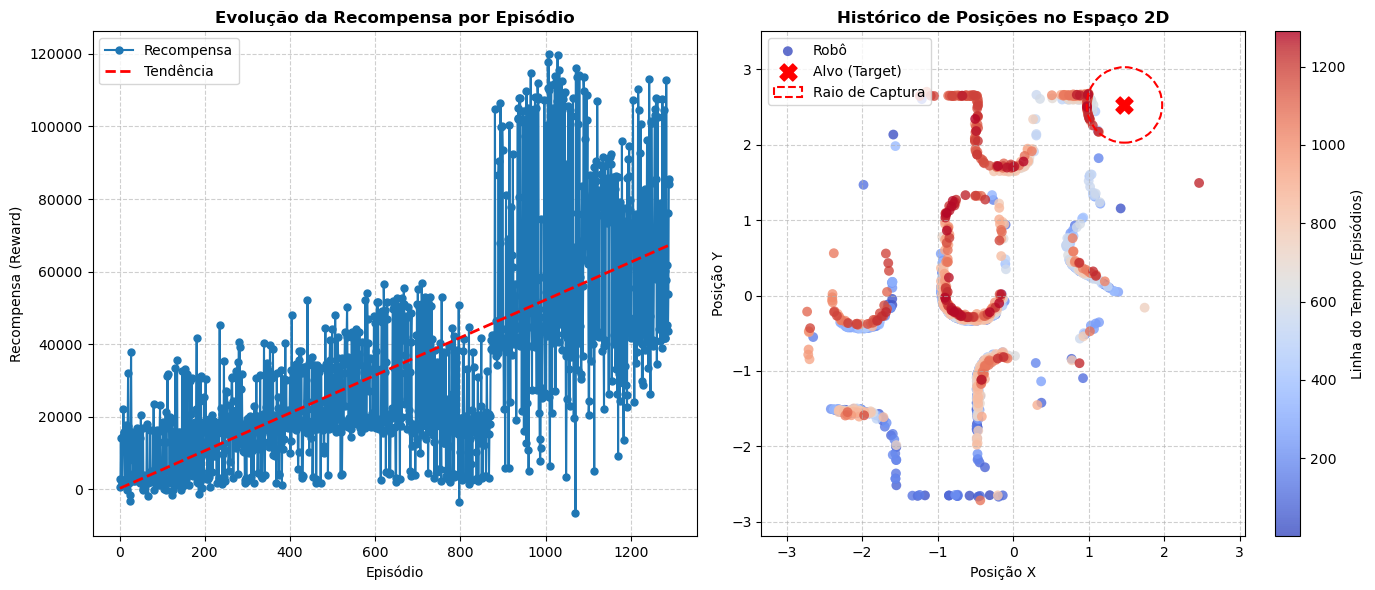

[INFO] Script finalizado com sucesso.


In [16]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np  # Importado para calcular a linha de tendência
import os

# ==========================================
# 1. CARREGAMENTO DOS DADOS
# ==========================================
arquivo_csv = 'Models/dqn/experiment_log.csv'

# Verificação profissional para evitar erros abruptos
if not os.path.exists(arquivo_csv):
    print(f"[ERRO] O arquivo '{arquivo_csv}' não foi encontrado. Verifique o caminho e tente novamente.")
    exit()

df = pd.read_csv(arquivo_csv)

# ==========================================
# 2. INSPEÇÃO DOS DADOS (PRINTS NO TERMINAL)
# ==========================================
pd.set_option('display.max_columns', None)
pd.set_option('display.width', 1000)

print("\n" + "="*60)
print(" 📊 VISÃO GERAL DOS DADOS (PRIMEIRAS LINHAS) ")
print("="*60)
print(df.head().to_string()) 

print("\n" + "="*60)
print(" 📈 RESUMO ESTATÍSTICO ")
print("="*60)
print(df.describe().round(2).to_string()) 
print("="*60 + "\n")

# ==========================================
# 3. CONFIGURAÇÃO E EXIBIÇÃO DOS GRÁFICOS
# ==========================================
print("[INFO] Gerando gráficos. Feche a janela de exibição para encerrar o script...")

plt.figure(figsize=(14, 6))

# --- GRÁFICO 1: Evolução da Recompensa ---
plt.subplot(1, 2, 1)
# Adicionado label='Recompensa' para identificar na legenda
plt.plot(df['episode'], df['reward'], marker='o', color='#1f77b4', linestyle='-', linewidth=1.5, markersize=5, label='Recompensa')

# --- CÁLCULO E PLOT DA LINHA DE TENDÊNCIA ---
# Ajusta uma reta (polinômio de grau 1) aos dados
z = np.polyfit(df['episode'], df['reward'], 1)
p = np.poly1d(z)
# Plota a linha de tendência em vermelho tracejado
plt.plot(df['episode'], p(df['episode']), color='red', linestyle='--', linewidth=2, label='Tendência')

# Customizações do gráfico 1
plt.title('Evolução da Recompensa por Episódio', fontsize=12, fontweight='bold')
plt.xlabel('Episódio')
plt.ylabel('Recompensa (Reward)')
plt.grid(True, linestyle='--', alpha=0.6)
plt.legend(loc='upper left') # Ativa a legenda para mostrar 'Recompensa' e 'Tendência'

# --- GRÁFICO 2: Posições do Robô e do Alvo ---
ax2 = plt.subplot(1, 2, 2)

# Plot das posições do robô (Coolwarm: vai do azul [início] para o vermelho [fim])
sc = plt.scatter(df['robot_x'], df['robot_y'], c=df['episode'], cmap='coolwarm', s=50, alpha=0.8, edgecolors='none', label='Robô')

# Pegando as coordenadas iniciais do alvo
target_x = df['target_x'].iloc[0]
target_y = df['target_y'].iloc[0]

# Plot do Alvo (Target)
plt.scatter(target_x, target_y, color='red', marker='X', s=150, zorder=5, label='Alvo (Target)')

# Adicionando o Círculo com Raio 0.5 em volta do alvo
circle = plt.Circle((target_x, target_y), 0.5, color='red', fill=False, linestyle='--', linewidth=1.5, label='Raio de Captura', zorder=4)
ax2.add_patch(circle)

# Força as escalas dos eixos X e Y a serem iguais para o círculo não virar uma elipse
ax2.set_aspect('equal', adjustable='datalim')

# Customizações do gráfico de posições
plt.title('Histórico de Posições no Espaço 2D', fontsize=12, fontweight='bold')
plt.xlabel('Posição X')
plt.ylabel('Posição Y')
plt.grid(True, linestyle='--', alpha=0.6)
plt.legend(loc='upper left')

# Barra de cores
cbar = plt.colorbar(sc)
cbar.set_label('Linha do Tempo (Episódios)')

# Exibir
plt.tight_layout()
plt.show()

print("[INFO] Script finalizado com sucesso.")